In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

from sklearn.neighbors import NearestNeighbors

In [2]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
print(df.shape)

print(df.info())

print(df.describe())

(13611, 17)
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(

In [4]:
print(df.isnull().sum())

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [5]:
print(df.duplicated().sum())

68


In [6]:
print(df['Class'].value_counts())

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [7]:
X = df.drop("Class", axis=1)

y = df["Class"]

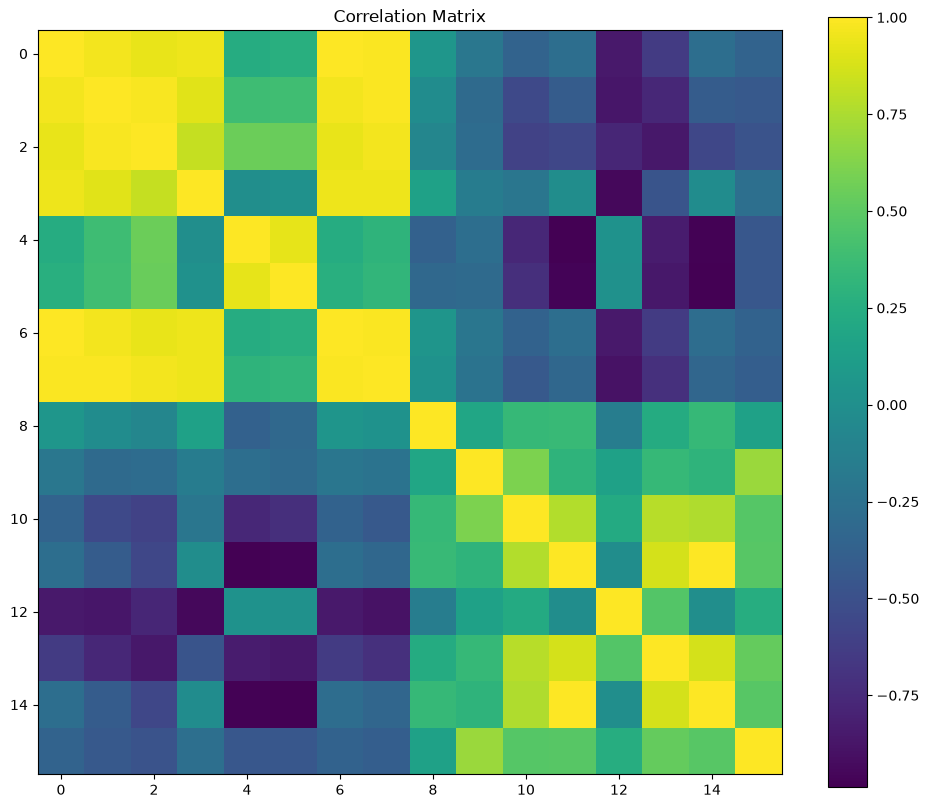

In [8]:
corr = X.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

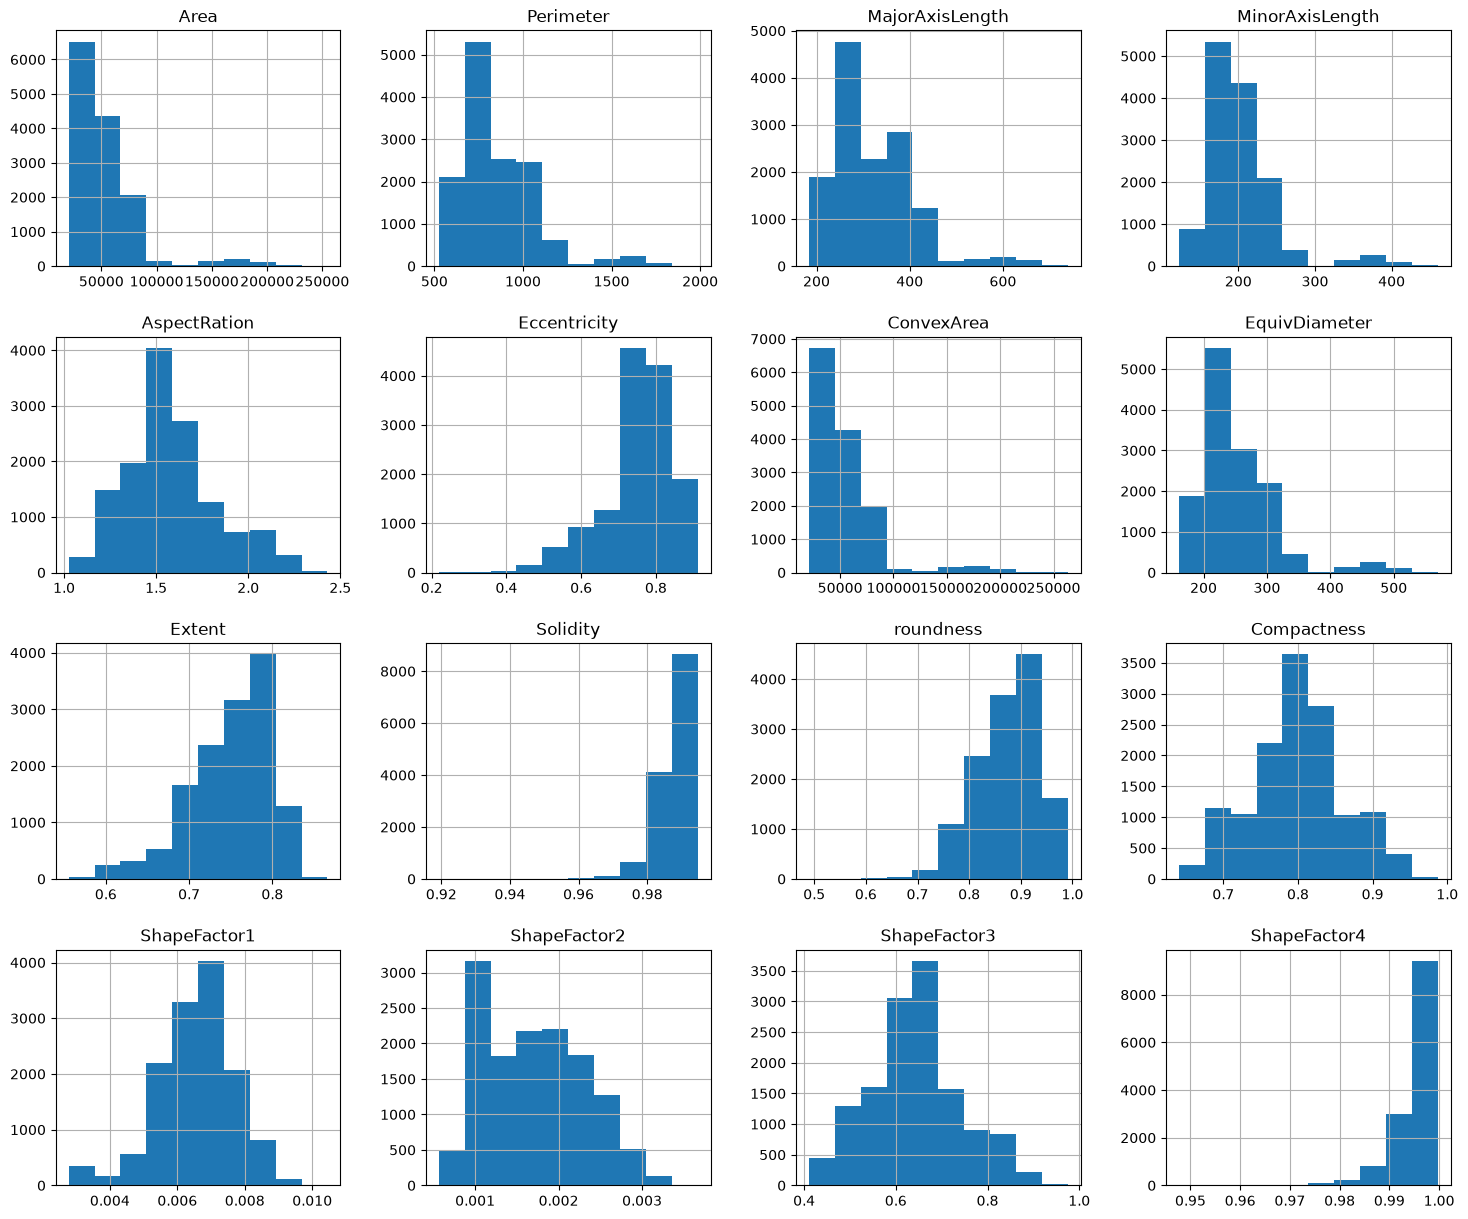

In [9]:
X.hist(figsize=(18,15))

plt.show()

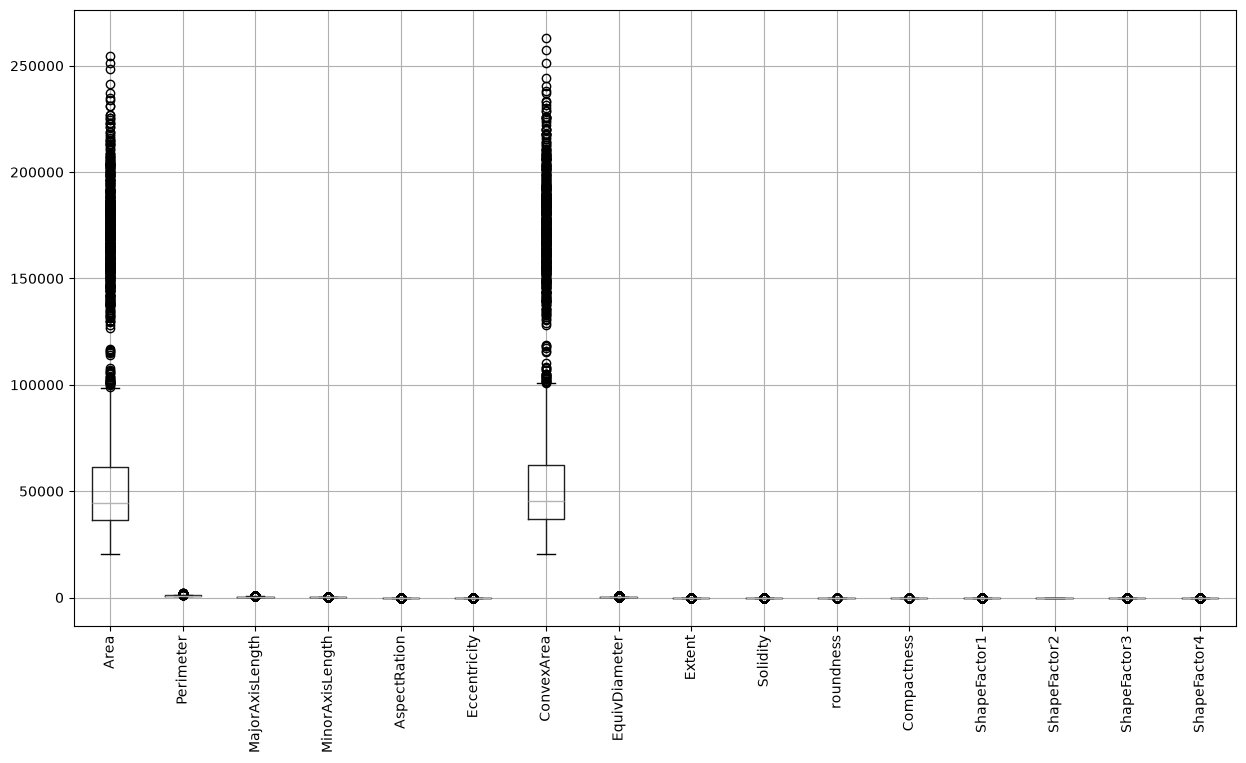

In [10]:
plt.figure(figsize=(15,8))

X.boxplot(rot=90)

plt.show()

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
model_ward = AgglomerativeClustering(
    n_clusters=7,
    linkage='ward'
)

labels_ward = model_ward.fit_predict(X_scaled)

In [13]:
model_complete = AgglomerativeClustering(
    n_clusters=7,
    linkage='complete'
)

labels_complete = model_complete.fit_predict(X_scaled)

In [14]:
model_average = AgglomerativeClustering(
    n_clusters=7,
    linkage='average'
)

labels_average = model_average.fit_predict(X_scaled)

In [15]:
model_single = AgglomerativeClustering(
    n_clusters=7,
    linkage='single'
)

labels_single = model_single.fit_predict(X_scaled)

In [16]:
print("Ward :", silhouette_score(X_scaled, labels_ward))

print("Complete :", silhouette_score(X_scaled, labels_complete))

print("Average :", silhouette_score(X_scaled, labels_average))

print("Single :", silhouette_score(X_scaled, labels_single))

Ward : 0.2838546811487893
Complete : 0.22815112957760772
Average : 0.4000156131593884
Single : 0.36262849405084313


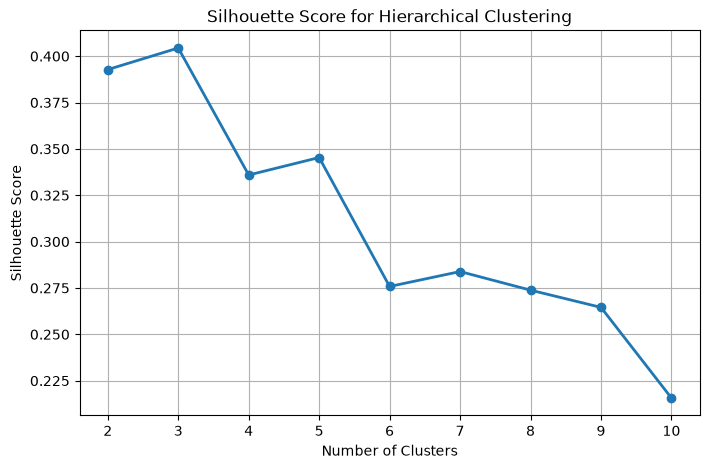

In [33]:
silhouette_scores = []
cluster_range = range(2, 11)

for k in cluster_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(8,5))
plt.plot(cluster_range, silhouette_scores, marker='o', linewidth=2)
plt.title("Silhouette Score for Hierarchical Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [34]:
best_k = cluster_range[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)

print("Best Number of Clusters:", best_k)
print("Best Silhouette Score:", best_score)

Best Number of Clusters: 3
Best Silhouette Score: 0.4044006038963992


In [17]:
sample = X_scaled[:1000]

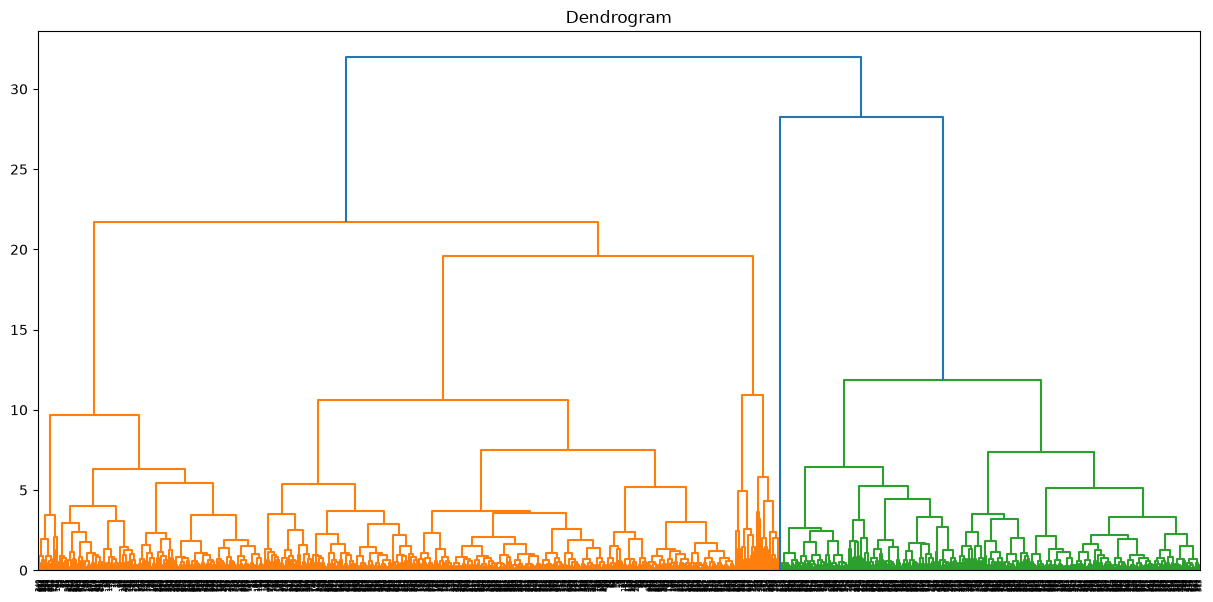

In [18]:
plt.figure(figsize=(15,7))

sch.dendrogram(
    sch.linkage(sample, method='ward')
)

plt.title("Dendrogram")

plt.show()

In [19]:
scores = []

for k in range(2,11):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print(k, score)

2 0.39277734772162515
3 0.4044006038963992
4 0.33592118199274557
5 0.34533654012924137
6 0.2758083953620766
7 0.2838546811487893
8 0.2738298582965628
9 0.26454365125042106
10 0.21567350939104588


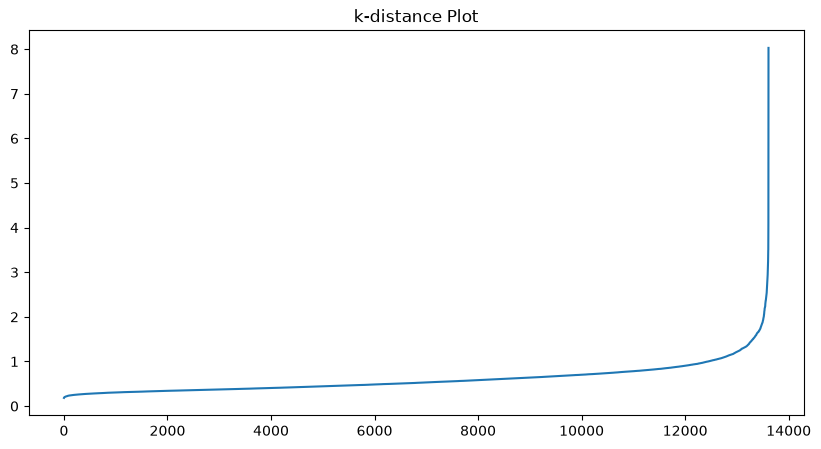

In [20]:
neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])

plt.figure(figsize=(10,5))

plt.plot(distances)

plt.title("k-distance Plot")

plt.show()

In [21]:
dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

In [22]:
noise = np.sum(db_labels==-1)

percentage = noise/len(db_labels)*100

print("Noise Percentage =", percentage)

Noise Percentage = 2.7845125266328705


In [23]:
print("Silhouette")

print(silhouette_score(X_scaled, labels_ward))

print("Davies Bouldin")

print(davies_bouldin_score(X_scaled, labels_ward))

Silhouette
0.2838546811487893
Davies Bouldin
1.1064420945358668


In [24]:
mask = db_labels != -1

print(silhouette_score(
    X_scaled[mask],
    db_labels[mask]
))

print(davies_bouldin_score(
    X_scaled[mask],
    db_labels[mask]
))

0.41085414610160925
0.8153340470328103


In [25]:
print(pd.Series(labels_ward).value_counts())

print(pd.Series(db_labels).value_counts())

4    3278
2    3063
0    3036
3    1918
1    1677
5     522
6     117
Name: count, dtype: int64
 0    12765
 1      451
-1      379
 2        6
 3        5
 4        5
Name: count, dtype: int64


In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

true_labels = encoder.fit_transform(y)

In [27]:
ari = adjusted_rand_score(
    true_labels,
    labels_ward
)

print(ari)

0.6579845646801203


In [28]:
nmi = normalized_mutual_info_score(
    true_labels,
    labels_ward
)

print(nmi)

0.7325285591840689


In [29]:
pd.crosstab(
    labels_ward,
    y
)

Class,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
row_0,,,,,,,
0,1268,0,1583,0,139,6,40
1,8,0,16,2,1622,0,29
2,0,0,0,2826,10,57,170
3,9,0,2,60,0,1834,13
4,36,0,15,658,59,129,2381
5,0,522,0,0,0,0,0
6,1,0,14,0,98,1,3


In [30]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

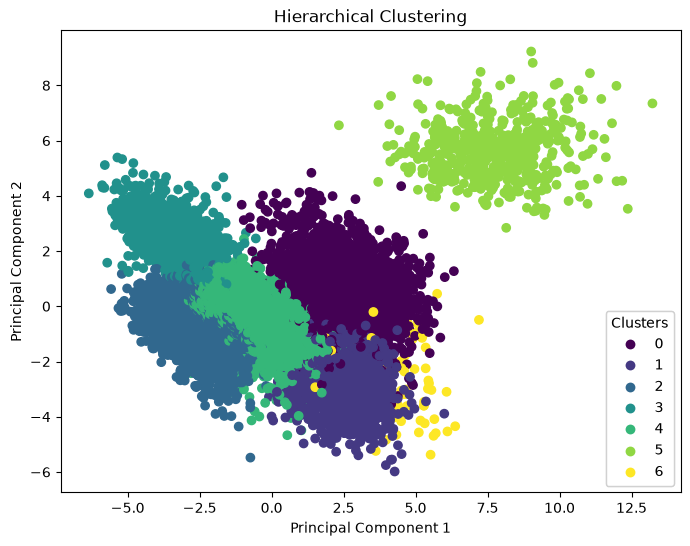

In [42]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_ward,
    cmap='viridis'
)

legend1 = plt.legend(*scatter.legend_elements(),
                     title="Clusters",
                     loc="best")
plt.gca().add_artist(legend1)

plt.title("Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

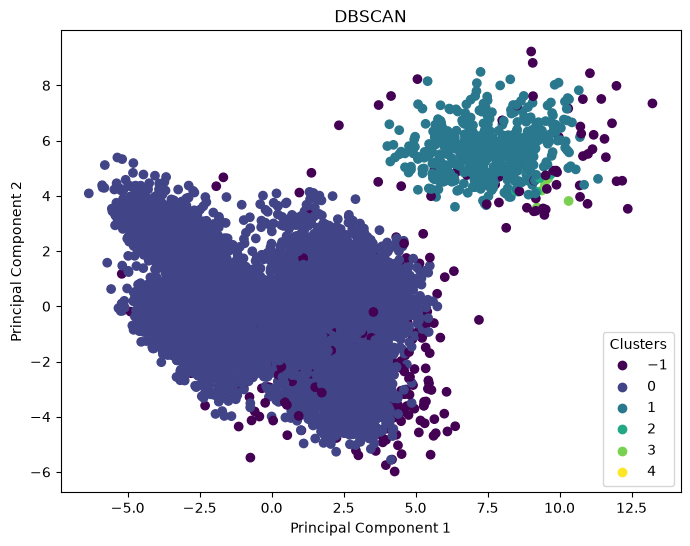

In [41]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=db_labels,
    cmap='viridis'
)

plt.legend(
    *scatter.legend_elements(),
    title="Clusters",
    loc="lower right"
)

plt.title("DBSCAN")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()